In [1]:
import numpy as np
import matplotlib.pyplot as plt
from girsanov_uq.utils.utils import compute_derivative_check, compute_relative_cumulant_error
import warnings
warnings.filterwarnings("ignore")


In [2]:
data_fit = np.load('./data_dimer/reweighting_aggregate.npz')
probs = np.concatenate([data_fit['ams_probabilities']], axis=0)
scores = np.concatenate([data_fit['all_scores']], axis=0)
fims = np.concatenate([data_fit['all_fims']], axis=0)




In [3]:
probs_hm = np.load('./data_dimer/probas_h-.npy')
probs_hp = np.load('./data_dimer/probas_h+.npy')
probs_hmm = np.load('./data_dimer/probas_h--.npy')
probs_hpp = np.load('./data_dimer/probas_h++.npy')
probs_epsilonm = np.load('./data_dimer/probas_epsilon-.npy')
probs_epsilonp = np.load('./data_dimer/probas_epsilon+.npy')
probs_epsilonmm = np.load('./data_dimer/probas_epsilon--.npy')
probs_epsilonpp = np.load('./data_dimer/probas_epsilon++.npy')


In [4]:
samples_h = [[0.5, probs_hpp], [-0.5, probs_hmm],[0.25, probs_hp], [-0.25, probs_hm], [0, probs]]
samples_epsilon = [[0.1, probs_epsilonpp],[0.05, probs_epsilonp],[-0.1, probs_epsilonmm], [-0.05, probs_epsilonm],[0,probs]]

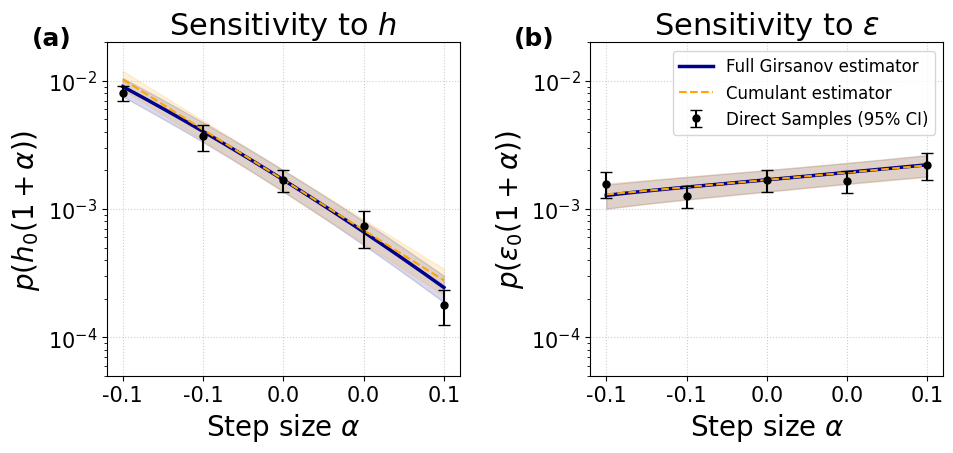

In [5]:
delta_theta = [1,0,0,0]
fig, axes = plt.subplots(1,2, figsize=(10,5 ))

# Left: sensitivity for delta_theta = [1,0,0,0]
compute_derivative_check(scores, fims, probs, delta_theta, alpha_range=0.5, samples=samples_h, ax=axes[0], theta_reference=5.0)
axes[0].set_yscale('log')
axes[0].set_ybound(5e-5, 2e-2)

# Right: sensitivity for delta_theta = [0,1,0,0]
delta_theta = [0,1,0,0]
compute_derivative_check(scores, fims, probs, delta_theta, alpha_range=0.1, samples=samples_epsilon, ax=axes[1], theta_reference=1.0)
axes[1].set_yscale('log')
axes[1].set_ybound(5e-5, 2e-2)

axes[0].set_title('Sensitivity to $h$')
axes[1].set_title('Sensitivity to $\epsilon$')

axes[0].legend().set_visible(False)
axes[1].legend(fontsize=12)

axes[0].set_ylabel(r'$p(h_0 (1+\alpha))$')
axes[1].set_ylabel(r'$p(\epsilon_0 (1+\alpha))$')

axes[0].text(-0.1, 1.05, '(a)', transform=axes[0].transAxes, fontsize=18, fontweight='bold', va='top', ha='right')
axes[1].text(-0.1, 1.05, '(b)', transform=axes[1].transAxes, fontsize=18, fontweight='bold', va='top', ha='right')

fig.tight_layout()
fig.savefig('dimer_SA_h_epsilon_subplot.png', dpi=300, bbox_inches='tight')

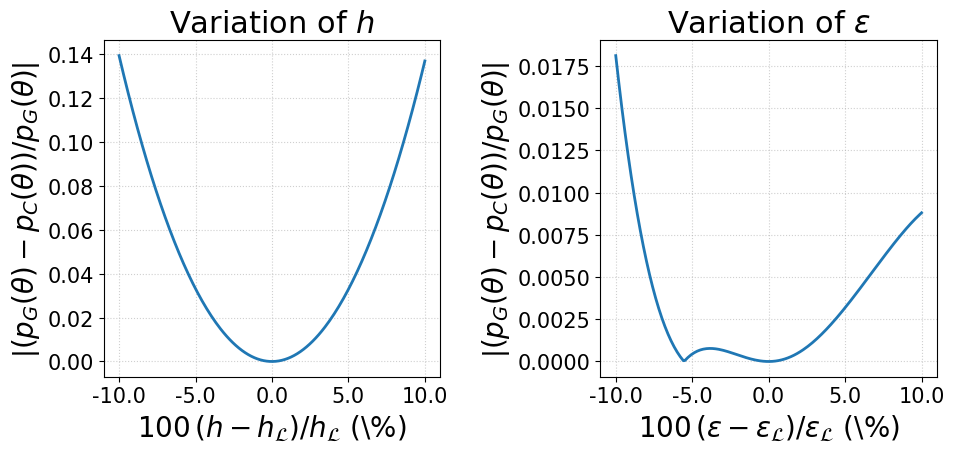

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

compute_relative_cumulant_error(
    scores, fims, probs, [1, 0, 0, 0], theta_reference=5.0,
    variation_percent_range=10.0, ax=axes[0]
)
compute_relative_cumulant_error(
    scores, fims, probs, [0, 1, 0, 0], theta_reference=1.0,
    variation_percent_range=10.0, ax=axes[1]
)

axes[0].set_title(r"Variation of $h$")
axes[1].set_title(r"Variation of $\epsilon$")
axes[0].set_xlabel(r"$100\,(h-h_{\mathcal{L}})/h_{\mathcal{L}}$ (\%)")
axes[1].set_xlabel(r"$100\,(\epsilon-\epsilon_{\mathcal{L}})/\epsilon_{\mathcal{L}}$ (\%)")

fig.tight_layout()